## Pose Graph Optimization with G2O
### Objective
A robot is travelling in a oval trajectory around a bunny point cloud. It is using ICP between consecutive frames to extract odometry. However, due to noise in the odometry it generates a noisy estimate of the trajectory. Once a loop is detected we get oracle knowledge regarding the pair of poses in the start and end of the loop.

Our task is to use loop closure pairs to correct the drift.

We pose this problem as a pose graph optimization problem. In our graph, poses are the vertices and constraints are the edges. 

References:

1.) Notes: https://saishubodh.notion.site/G2O-Edge-Types-d9f9ff63c77c4ceeb84b1e49085004e3

2.) Cyrill Stachniss lecture: https://www.youtube.com/watch?v=uHbRKvD8TWg

### Data Generation:

In a real-world setting, this data would come from a robot and its sensors. Here, we simulate the same scenario for experimentation and visualization.

- A 3D object (Stanford bunny mesh) is loaded and processed into a point cloud.
- We simulate a robot moving in an elliptical path around the object. Ground-truth positions are recorded at each step.
- At each step, the robot captures a partial, noisy view of the point cloud. These views are used to simulate odometry using ICP, with noisy initial guesses to simulate realistic drift.
- As ICP is applied pairwise between consecutive poses, alignment drift accumulates over time.
- After completing a loop, we simulate loop closure by inserting a ground-truth-based (oracle) edge between the final and initial poses.
- The generated data (ground truth and noisy odometry edges) is saved in g2o format.
- Finally, we animate the ground truth and drifted trajectories to visualize the effects of accumulated error and loop closure.

In [1]:
## INCLUDES AND HELPER FUNCTIONS
import open3d as o3d
import numpy as np
import os
import copy
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import math

def normalize_angle(angle):
    return np.arctan2(np.sin(angle), np.cos(angle))

def pose_to_matrix(pose):
    x, y, theta = pose
    return np.array([
        [np.cos(theta), -np.sin(theta), 0, x],
        [np.sin(theta),  np.cos(theta), 0, y],
        [0,             0,             1, 0],
        [0,             0,             0, 1]
    ])

def matrix_to_g2o_2d(matrix):
    dx = matrix[0, 3]
    dy = matrix[1, 3]
    dtheta = np.arctan2(matrix[1, 0], matrix[0, 0])
    return dx, dy, normalize_angle(dtheta)

def readVertex(fileName):
    f = open(fileName, 'r')
    A = f.readlines()
    f.close()
    x_arr, y_arr, theta_arr = [], [], []
    for line in A:
        if "VERTEX_SE2" in line:
            (ver, ind, x, y, theta) = line.split()
            x_arr.append(float(x))
            y_arr.append(float(y))
            theta_arr.append(float(theta.rstrip('\\n')))
    return np.array([x_arr, y_arr, theta_arr])

def readEdge(fileName):
    f = open(fileName, 'r')
    A = f.readlines()
    f.close()
    ind1_arr, ind2_arr, del_x, del_y, del_theta, info_arr = [], [], [], [], [], []
    for line in A:
        if "EDGE_SE2" in line:
            parts = line.split()
            ind1_arr.append(int(parts[1]))
            ind2_arr.append(int(parts[2]))
            del_x.append(float(parts[3]))
            del_y.append(float(parts[4]))
            del_theta.append(float(parts[5]))
            info_arr.append(" ".join(parts[6:12])) 
    return (np.array(ind1_arr), np.array(ind2_arr), np.array(del_x), np.array(del_y), np.array(del_theta), info_arr)

def draw(X, Y, THETA, title):
    ax = plt.subplot(111)
    ax.plot(X, Y, 'ro')
    plt.plot(X, Y, 'c-')
    for i in range(len(THETA)):
        x2 = 0.25 * math.cos(THETA[i]) + X[i]
        y2 = 0.25 * math.sin(THETA[i]) + Y[i]
        plt.plot([X[i], x2], [Y[i], y2], 'g->')
    plt.title(title)
    plt.grid(True)
    plt.axis('equal')
    plt.show()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
NUM_POSES = 50
def generate_data_and_animate(output_dir="./data", NUM_POSES=NUM_POSES):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    print("--- Starting Final, Verified ICP Data Generation ---")

    # 1. --- Parameters ---
    RADIUS_X = 8.0
    RADIUS_Y = 6.0
    POINT_CLOUD_NOISE_STD = 0.01
    ODOM_POS_NOISE_STD = 0.08
    ODOM_ANGLE_NOISE_STD = np.deg2rad(2.0)
    LC_POS_NOISE_STD = 0.01
    LC_ANGLE_NOISE_STD = np.deg2rad(0.2)
    
    odom_info_str = "500.0 0.0 0.0 500.0 0.0 500.0"
    lc_info_str = "2000.0 0.0 0.0 2000.0 0.0 2000.0"

    # 2. --- Load and Prepare Object ---
    print("Loading and preparing 3D object...")
    bunny_mesh = o3d.data.BunnyMesh()
    object_pcd = o3d.io.read_point_cloud(bunny_mesh.path)
    object_pcd.scale(60, center=object_pcd.get_center())
    object_pcd.translate(-object_pcd.get_center())
    object_pcd.rotate(o3d.geometry.get_rotation_matrix_from_xyz((np.pi/2, 0, 0)))
    master_pcd = copy.deepcopy(object_pcd).voxel_down_sample(voxel_size=0.1)
    master_pcd.estimate_normals()

    # 3. --- Generate Ground Truth and Partial Views ---
    print("Generating ground truth path and partial camera views...")
    gt_poses = []
    camera_views = []
    t_space = np.linspace(0, 2 * np.pi, NUM_POSES, endpoint=False)
    for t in t_space:
        x = RADIUS_X * np.cos(t)
        y = RADIUS_Y * np.sin(t)
        theta = np.arctan2(RADIUS_Y * np.cos(t), -RADIUS_X * np.sin(t))
        gt_poses.append([x, y, normalize_angle(theta)])
        
        camera_location = [x, y, 5.0]
        _, pt_map = master_pcd.hidden_point_removal(camera_location, radius=100)
        view_pcd = master_pcd.select_by_index(pt_map)
        
        points = np.asarray(view_pcd.points)
        points += np.random.normal(0, POINT_CLOUD_NOISE_STD, size=points.shape)
        view_pcd.points = o3d.utility.Vector3dVector(points)
        camera_views.append(view_pcd)
    gt_poses = np.array(gt_poses)

    # 4. --- Simulate Noisy Edges using Local Frame ICP ---
    print("Generating noisy odometry from ICP...")
    edges = []
    
    for i in range(NUM_POSES - 1):
        # Create the point clouds in their respective LOCAL camera frames
        T_world_to_i = np.linalg.inv(pose_to_matrix(gt_poses[i]))
        target_pcd_local = copy.deepcopy(object_pcd).transform(T_world_to_i)
        target_pcd_local = target_pcd_local.select_by_index(o3d.geometry.KDTreeFlann(target_pcd_local).search_knn_vector_3d([0,0,0], 1000)[1])


        T_world_to_i_plus_1 = np.linalg.inv(pose_to_matrix(gt_poses[i+1]))
        source_pcd_local = copy.deepcopy(object_pcd).transform(T_world_to_i_plus_1)
        source_pcd_local = source_pcd_local.select_by_index(o3d.geometry.KDTreeFlann(source_pcd_local).search_knn_vector_3d([0,0,0], 1000)[1])

        # Add sensor noise
        points = np.asarray(source_pcd_local.points)
        points += np.random.normal(0, POINT_CLOUD_NOISE_STD, size=points.shape)
        source_pcd_local.points = o3d.utility.Vector3dVector(points)
        
        source_pcd_local.estimate_normals()
        target_pcd_local.estimate_normals()

        # Create a noisy initial guess of the relative motion T_{i <- i+1}
        T_true_measurement = np.linalg.inv(pose_to_matrix(gt_poses[i])) @ pose_to_matrix(gt_poses[i+1])
        motion_model_noise = pose_to_matrix([
            np.random.normal(0, ODOM_POS_NOISE_STD),
            np.random.normal(0, ODOM_POS_NOISE_STD),
            np.random.normal(0, ODOM_ANGLE_NOISE_STD)
        ])
        initial_guess = T_true_measurement @ motion_model_noise
        
        # ICP refines this guess. The result IS the g2o edge measurement.
        reg_result = o3d.pipelines.registration.registration_icp(
            source_pcd_local, target_pcd_local, 0.2, initial_guess,
            o3d.pipelines.registration.TransformationEstimationPointToPlane())

        T_icp_measurement = reg_result.transformation
        dx, dy, dtheta = matrix_to_g2o_2d(T_icp_measurement)
        edges.append((i, i + 1, dx, dy, dtheta, odom_info_str))

    # Oracle Loop Closure Edge
    print("Generating oracle loop closure from ground truth...")
    T_world_last = pose_to_matrix(gt_poses[-1])
    T_world_first = pose_to_matrix(gt_poses[0])
    T_lc_true = np.linalg.inv(T_world_last) @ T_world_first
    dx_lc, dy_lc, dtheta_lc = matrix_to_g2o_2d(T_lc_true)
    dx_lc_noisy = dx_lc + np.random.normal(0, LC_POS_NOISE_STD)
    dy_lc_noisy = dy_lc + np.random.normal(0, LC_POS_NOISE_STD)
    dtheta_lc_noisy = dtheta_lc + np.random.normal(0, LC_ANGLE_NOISE_STD)
    edges.append((NUM_POSES - 1, 0, dx_lc_noisy, dy_lc_noisy, dtheta_lc_noisy, lc_info_str))

    # 5. --- Write Files ---
    print("Writing gt.txt and edges.txt files...")
    with open(os.path.join(output_dir, 'gt.txt'), 'w') as f:
        for i, pose in enumerate(gt_poses):
            f.write(f"VERTEX_SE2 {i} {pose[0]:.6f} {pose[1]:.6f} {pose[2]:.6f}\n")
    with open(os.path.join(output_dir, 'edges.txt'), 'w') as f:
        f.write(f"VERTEX_SE2 0 {gt_poses[0][0]:.6f} {gt_poses[0][1]:.6f} {gt_poses[0][2]:.6f}\n")
        for edge in edges:
            i, j, dx, dy, dtheta, info = edge
            f.write(f"EDGE_SE2 {i} {j} {dx:.6f} {dy:.6f} {dtheta:.6f} {info}\n")

    # 6. --- Animate Results ---
    print("Preparing animation...")
    drifted_poses_mat = [pose_to_matrix(gt_poses[0])]
    for i in range(NUM_POSES - 1):
        _, _, dx, dy, dtheta, _ = edges[i]
        T_measurement = pose_to_matrix([dx, dy, dtheta])
        last_drifted_pose = drifted_poses_mat[-1]
        current_drifted_pose = last_drifted_pose @ T_measurement
        drifted_poses_mat.append(current_drifted_pose)

    gt_x, gt_y = gt_poses[:, 0], gt_poses[:, 1]
    drifted_x = np.array([p[0, 3] for p in drifted_poses_mat])
    drifted_y = np.array([p[1, 3] for p in drifted_poses_mat])
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_xlim(gt_x.min() - 2, gt_x.max() + 2)
    ax.set_ylim(gt_y.min() - 2, gt_y.max() + 2)
    ax.set_title('Ground Truth (Blue) vs. Accumulated Drift (Red)')
    ax.grid(True)
    ax.set_aspect('equal', adjustable='box')
    
    gt_line, = ax.plot([], [], 'b-o', label='Ground Truth Path', alpha=0.5)
    drifted_line, = ax.plot([], [], 'r-x', label='Drifted Path (from ICP)')

    ax.legend()

    def animate(i):
        gt_line.set_data(gt_x[:i+1], gt_y[:i+1])
        drifted_line.set_data(drifted_x[:i+1], drifted_y[:i+1])
        return (gt_line, drifted_line)

    anim = FuncAnimation(fig, animate, frames=len(drifted_x), interval=50, blit=True)
    display(HTML(anim.to_jshtml()))
    plt.close(fig)
    
    print("--- Data generation complete! ---")

# Run the simulation
generate_data_and_animate()

--- Starting Final, Verified ICP Data Generation ---
Loading and preparing 3D object...
Generating ground truth path and partial camera views...
Generating noisy odometry from ICP...
Generating oracle loop closure from ground truth...
Writing gt.txt and edges.txt files...
Preparing animation...


--- Data generation complete! ---


### Let's use G2O: 
Now we have obtained the below after running our Data Generation Pipeline

1. Initial position
2. Odometry Contraints/Edges: This "edge" information tells us relative transformation between two nodes. These two nodes are consecutive in the case of Odometry but not in the case of Loop Closure (next point).
3. Loop Closure Contraints/Edges: Remember that while optimizing, you have another kind of "anchor" edge.

We now have been a text file named `edges.txt` (in `data/`) which has all the above 3 and it follows G2O's format (as explained in [link here](https://saishubodh.notion.site/G2O-Edge-Types-d9f9ff63c77c4ceeb84b1e49085004e3) ). The ground truth is `gt.txt`.

Install g2o as mentioned in `g2o.ipynb` and now we optimise `edges.txt`

GT Vertices shape: (3, 50)


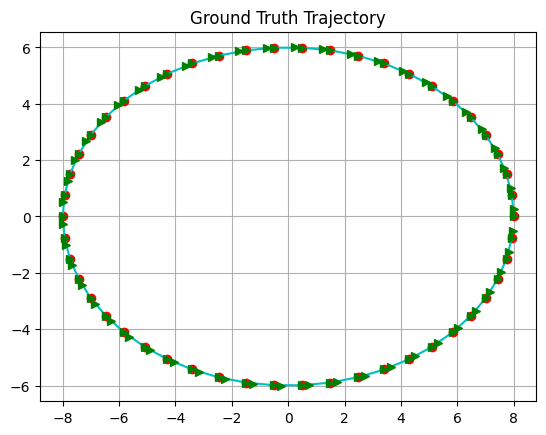

In [3]:
# Plot the Ground Truth Data
gt_file = "./data/gt.txt"
gt_vertex = readVertex(gt_file)
print(f"GT Vertices shape: {gt_vertex.shape}")
draw(gt_vertex[0], gt_vertex[1], gt_vertex[2], "Ground Truth Trajectory")

Generating initial state for ./data/edges.g2o...
Read 50 total edges from ./data/edges.txt
Generated ./data/edges.g2o with 50 vertices.


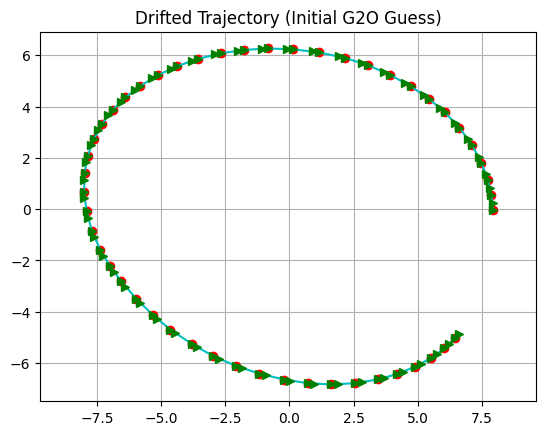

In [4]:
edges_file = "./data/edges.txt"
g2o_file = "./data/edges.g2o"

print(f"Generating initial state for {g2o_file}...")

# Read the initial pose and ALL edges (odometry + loop closure)
initial_pose_vertex = readVertex(edges_file)
ind1, ind2, dx, dy, dtheta, info_strings = readEdge(edges_file)
print(f"Read {len(ind1)} total edges from {edges_file}") # Should be NUM_POSES

INITIAL_POSE_NOISE_STD_POS = 0.05 # 5cm noise
INITIAL_POSE_NOISE_STD_ANGLE = np.deg2rad(1.0) # 1 degree noise

noisy_initial_pose_2d = initial_pose_vertex.flatten().copy()
noisy_initial_pose_2d[0] += np.random.normal(0, INITIAL_POSE_NOISE_STD_POS)
noisy_initial_pose_2d[1] += np.random.normal(0, INITIAL_POSE_NOISE_STD_POS)
noisy_initial_pose_2d[2] = normalize_angle(noisy_initial_pose_2d[2] + np.random.normal(0, INITIAL_POSE_NOISE_STD_ANGLE))

drifted_poses_mat = [pose_to_matrix(noisy_initial_pose_2d)]

# The first (NUM_POSES - 1) edges are odometry. The last one is the loop closure.
for i in range(NUM_POSES - 1):
    measurement = pose_to_matrix([dx[i], dy[i], dtheta[i]])
    last_drifted_pose = drifted_poses_mat[-1]
    current_drifted_pose = last_drifted_pose @ measurement
    drifted_poses_mat.append(current_drifted_pose)

with open(g2o_file, "w") as out:
    for i, pose_mat in enumerate(drifted_poses_mat):
        x = pose_mat[0, 3]
        y = pose_mat[1, 3]
        theta = normalize_angle(np.arctan2(pose_mat[1, 0], pose_mat[0, 0]))
        out.write(f"VERTEX_SE2 {i} {x:.6f} {y:.6f} {theta:.6f}\n")

    # Write ALL constraint edges (odometry AND loop closure)
    for i in range(len(ind1)): # This loops over all edges
        out.write(f"EDGE_SE2 {ind1[i]} {ind2[i]} {dx[i]:.6f} {dy[i]:.6f} {dtheta[i]:.6f} {info_strings[i]}\n")

    # Fix the first pose
    out.write("FIX 0\n")

print(f"Generated {g2o_file} with {len(drifted_poses_mat)} vertices.")

drifted_poses_arr = np.array([
    [p[0, 3] for p in drifted_poses_mat],
    [p[1, 3] for p in drifted_poses_mat],
    [np.arctan2(p[1, 0], p[0, 0]) for p in drifted_poses_mat]
])
draw(drifted_poses_arr[0], drifted_poses_arr[1], drifted_poses_arr[2], "Drifted Trajectory (Initial G2O Guess)")

In [5]:
os.environ["PATH"] += ":VanillaLoopClosure/g2o/build/bin"

In [6]:
def optimize():
    input_g2o = "./data/edges.g2o"
    output_g2o = "./data/optimal.g2o"
    cmd = f"g2o -o {output_g2o} {input_g2o}"
    print(f"Running command: {cmd}")
    os.system(cmd)
    print("Optimization finished.")

optimize()

Running command: g2o -o ./data/optimal.g2o ./data/edges.g2o
Optimization finished.


Read input from ./data/edges.g2o
Loaded 50 vertices
Loaded 50 edges
# graph is fixed by priors or already fixed vertex
Initial chi2 = 41425.649801
saving ./data/optimal.g2o ... done.


Optimized Vertices shape: (3, 50)


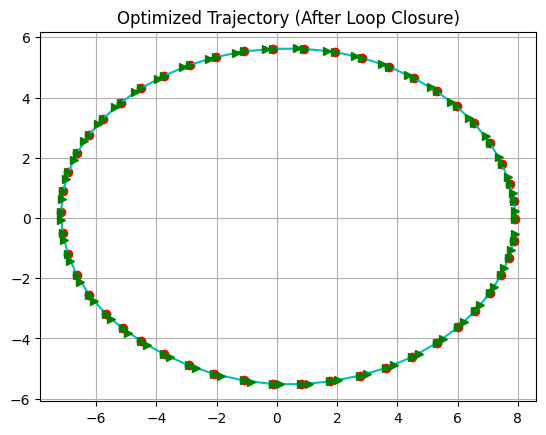

In [7]:
# Plot the Optimized Data
optimized_file = "./data/optimal.g2o"
optimized_vertex = readVertex(optimized_file)
print(f"Optimized Vertices shape: {optimized_vertex.shape}")
draw(optimized_vertex[0], optimized_vertex[1], optimized_vertex[2], "Optimized Trajectory (After Loop Closure)")

In [8]:
os.system("QT_QPA_PLATFORM=xcb g2o_viewer ./data/edges.g2o")

0

Drifted APE - Mean: 1.8417 m, Max: 4.5381 m
Optimized APE - Mean: 0.5785 m, Max: 0.8614 m


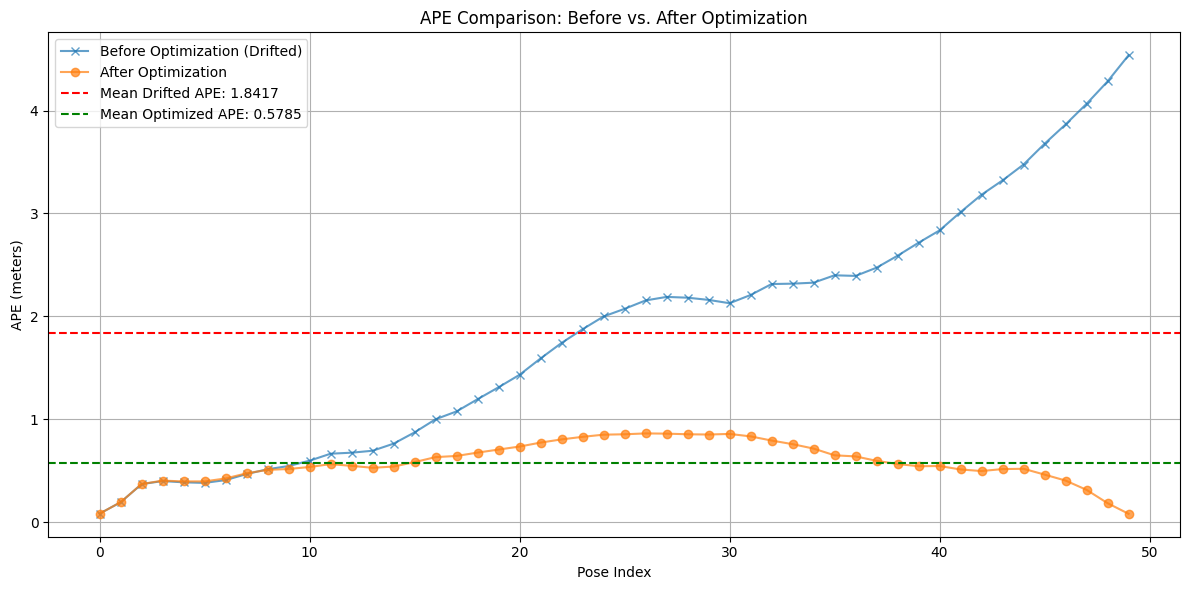

In [9]:
# APE Comparison: Before vs. After Optimization
def compute_ape(gt, est):
    """Compute Absolute Pose Error (APE): Euclidean distance between GT and estimated pose"""
    return np.linalg.norm(gt[:2, :] - est[:2, :], axis=0)

# Load data
gt_poses = readVertex("./data/gt.txt")
opt_poses = readVertex("./data/optimal.g2o")
drifted_poses = drifted_poses_arr  # Already computed earlier

# Ensure consistency
assert gt_poses.shape[1] == opt_poses.shape[1] == drifted_poses.shape[1], "Mismatch in trajectory lengths"

# Compute APEs
ape_drifted = compute_ape(gt_poses, drifted_poses)
ape_optimized = compute_ape(gt_poses, opt_poses)

# Print comparison stats
print(f"Drifted APE - Mean: {np.mean(ape_drifted):.4f} m, Max: {np.max(ape_drifted):.4f} m")
print(f"Optimized APE - Mean: {np.mean(ape_optimized):.4f} m, Max: {np.max(ape_optimized):.4f} m")

# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(ape_drifted, label="Before Optimization (Drifted)", marker='x', alpha=0.7)
plt.plot(ape_optimized, label="After Optimization", marker='o', alpha=0.7)
plt.axhline(np.mean(ape_drifted), color='r', linestyle='--', label=f"Mean Drifted APE: {np.mean(ape_drifted):.4f}")
plt.axhline(np.mean(ape_optimized), color='g', linestyle='--', label=f"Mean Optimized APE: {np.mean(ape_optimized):.4f}")
plt.title("APE Comparison: Before vs. After Optimization")
plt.xlabel("Pose Index")
plt.ylabel("APE (meters)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
